# Multiclass machine failure prediction Analysis

This notebook focus on determining a supervised machine learning model that most precisely predicts which kind of failure our machinery have, as it continues the work done in the lab from the link as follows:

In [9]:
import pandas as pd
import zipfile
import numpy as np
import io
import os
import requests
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, make_scorer
)
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE,SVMSMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import optuna
from sklearn.metrics import matthews_corrcoef, make_scorer
import shap
from sklearn.base import clone
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.multioutput import MultiOutputClassifier

In [10]:
URL = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(URL, headers=headers)

In [11]:
zip_buffer = io.BytesIO(response.content)
with zipfile.ZipFile(zip_buffer) as z:     
    csv_files = z.namelist()
    print(f"Arquivos encontrados: {csv_files}")
    f = z.open(csv_files[0])
    print(f"Carregando: {f}...")
    df = pd.read_csv(f)

Arquivos encontrados: ['ai4i2020.csv']
Carregando: <zipfile.ZipExtFile name='ai4i2020.csv' mode='r'>...


In [12]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Data used

As a continuity of our binary machine failure analysis, we will use only the following features:

|Feature Name|
|-------|
|Rotational Speed|
|Tool Wear|
|Type|
|Torque|
|Temp_Diff|

Being Temp_Diff = Air temperature - Process Temperature

In [13]:
X = df[['Rotational speed [rpm]','Tool wear [min]','Type','Torque [Nm]']]
X['Temp_Diff'] = df['Air temperature [K]'] - df['Process temperature [K]']
Y = df[['TWF','HDF','PWF','OSF','RNF']]

In [14]:
X.head()

,Rotational speed [rpm],Tool wear [min],Type,Torque [Nm],Temp_Diff
0,1551,0,M,42.8,-10.5
1,1408,3,L,46.3,-10.5
2,1498,5,L,49.4,-10.4
3,1433,7,L,39.5,-10.4
4,1408,9,L,40.0,-10.5


Now in this case, we will not have the target variable Machine Failure, but all the 5 kinds of machine failure

In [15]:
Y.head()

,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


### Determining what kind of analysis are going to be done

Now, it is important to check a detail in our data, that might change completely the way we are going to build our model.

If there is more than one failure occuring at once, we would need a Multiclass analysis. However, if there are none, or at least a very low number of cases which more than one failure happens at once, we could use a single target variable, with values ranging from 0 (no failures), up to 5

In [16]:
print(Y.shape)        # (n_amostras, 5) → multi-label
print(Y.sum(axis=1).max()) 
print(Y.sum(axis=1).value_counts().sort_index())

# How many simultaneous failures exists
#print(Y.astype(str).apply('_'.join, axis=1).value_counts().head(20))

print(f"Percentage of multiple failures occuring at once: {((Y.sum(axis=1)==2)|(Y.sum(axis=1) == 3)).sum()/(Y.sum(axis=1)==1).sum():.2%}")

(10000, 5)
3
0    9652
1     324
2      23
3       1
Name: count, dtype: int64
Percentage of multiple failures occuring at once: 7.41%


As seen, we have 7.4% of our total failures being more than 1 failure at once. It is a small number for some applications, but since we are talking about machinery maintenance, one prediction that does not take into account another mode of failure, might be the same as leaving the machine to fail, and 7.4% is a number to be considered

So, we are going to make a multiclass analysis.

### Baseline Model

As seen in our machine failure notebook, RFC performed very well, so we are going to use an untuned Random Forests Classifier as a baseline model for our predictor.

In [17]:
pipelines_resultados = {}

scores = {
    'f1_micro':    make_scorer(f1_score, average='micro', zero_division=0),
    'f1_macro':    make_scorer(f1_score, average='macro', zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)
        }


from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import multilabel_confusion_matrix


mss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in mss.split(X, Y):
    x_train, x_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

cv = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)
    ])

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight = 'balanced')) 
])

pipelines_resultados['RFC_baseline'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test), target_names=list(Y.columns)),multilabel_confusion_matrix(y_test,pipe.predict(x_test))]


C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Use

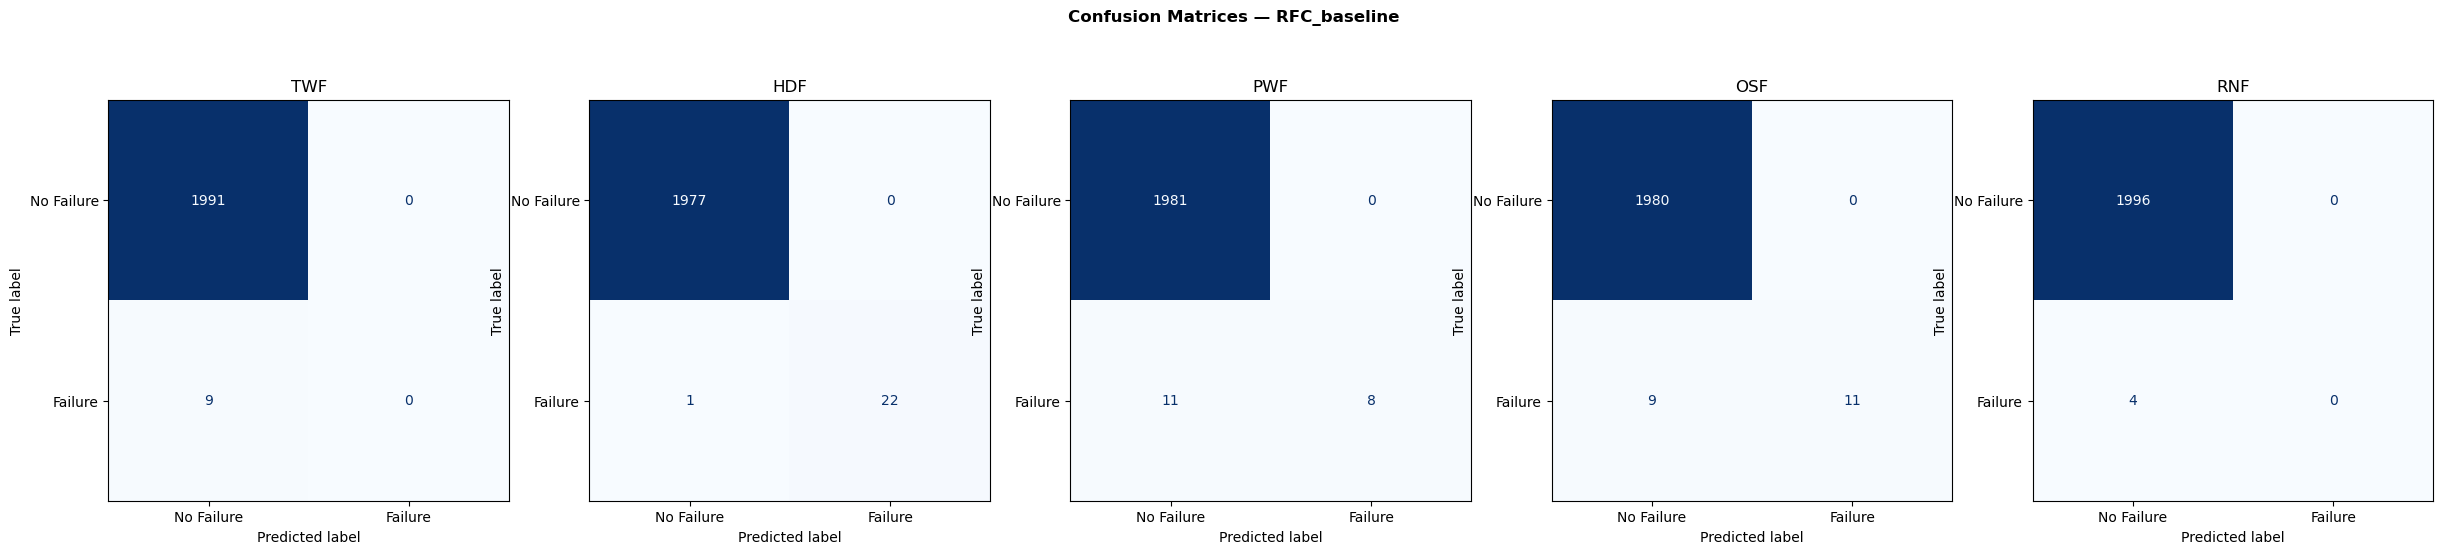

In [23]:

fig, axes = plt.subplots(1, 5, figsize=(30,6))
label_names = Y.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_baseline'][-1][i], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[0]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin
class MultiLabelOversampledCV:
    """Aplica oversampling apenas no fold de treino, sem data leakage"""
    
    def __init__(self, estimator, cv, use_oversampler=True):
        self.estimator = estimator
        self.cv = cv
        self.use_oversampler = use_oversampler
    
    def score(self, X, y):
        scores = []
        
        # Mantém como DataFrame para preservar nomes das colunas
        X_df  = X.reset_index(drop=True)
        y_arr = y.values if hasattr(y, 'values') else y
        
        for train_idx, test_idx in self.cv.split(X_df, y_arr):
            X_train_fold = X_df.iloc[train_idx]
            X_test_fold  = X_df.iloc[test_idx]
            y_train_fold = y_arr[train_idx]
            y_test_fold  = y_arr[test_idx]
            
            if self.use_oversampler:
                # Converte multilabel → string para o RandomOverSampler aceitar
                y_str = [''.join(map(str, row)) for row in y_train_fold]
                ros   = RandomOverSampler(random_state=42)
                X_train_fold, y_str_res = ros.fit_resample(X_train_fold, y_str)
                y_train_fold = np.array([[int(c) for c in s] for s in y_str_res])
                
                # Reconverte X para DataFrame preservando colunas
                X_train_fold = pd.DataFrame(X_train_fold, columns=X_df.columns)
            
            self.estimator.fit(X_train_fold, y_train_fold)
            y_pred = self.estimator.predict(X_test_fold)
            scores.append(f1_score(y_test_fold, y_pred, average='micro', zero_division=0))
        
        return np.mean(scores)


def objective(trial):

    model_name      = trial.suggest_categorical('model', ['RFC', 'XGB'])
    use_oversampler = trial.suggest_categorical('use_oversampler', [True, False])
    class_weight    = trial.suggest_categorical('class_weight', [None, 'balanced'])

    if model_name == 'RFC':
        model = RandomForestClassifier(
            n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
            max_depth         = trial.suggest_int('max_depth', 3, 20),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
            max_features      = trial.suggest_float('max_features', 0.3, 0.9),
            class_weight      = class_weight,
            random_state      = 42,
            n_jobs            = -1
        )

    else:
        model = XGBClassifier(
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
            max_depth        = trial.suggest_int('max_depth', 3, 10),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            gamma            = trial.suggest_float('gamma', 0, 5),
            random_state     = 42,
            n_jobs           = -1,
            verbosity        = 0
        )


    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   MultiOutputClassifier(model))
    ])
    
    cv_runner = MultiLabelOversampledCV(
        estimator      = pipe,
        cv             = cv,
        use_oversampler = use_oversampler
    )

    return cv_runner.score(x_train, y_train)

In [14]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), pruner = optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f"\nMelhor modelo:       {study.best_params['model']}")

print(f"Melhor F1-micro:     {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

[I 2026-03-10 11:35:51,533] A new study created in memory with name: no-name-190ec146-d79a-4aad-9a6c-fb6d28bc37d3
Best trial: 0. Best value: 0.546375:   0%|          | 1/300 [02:28<12:20:42, 148.64s/it]

[I 2026-03-10 11:38:20,184] Trial 0 finished with value: 0.5463749548523434 and parameters: {'model': 'XGB', 'use_oversampler': True, 'class_weight': None, 'learning_rate': 0.012184186502221764, 'n_estimators': 880, 'max_depth': 7, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'min_child_weight': 10, 'gamma': 4.162213204002109}. Best is trial 0 with value: 0.5463749548523434.


Best trial: 1. Best value: 0.729232:   1%|          | 2/300 [03:10<7:07:28, 86.07s/it]  

[I 2026-03-10 11:39:02,451] Trial 1 finished with value: 0.7292318265926513 and parameters: {'model': 'RFC', 'use_oversampler': False, 'class_weight': None, 'n_estimators': 362, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5198171059762151}. Best is trial 1 with value: 0.7292318265926513.


Best trial: 1. Best value: 0.729232:   1%|          | 3/300 [03:16<4:04:48, 49.46s/it]

...

[I 2026-03-10 20:49:51,850] Trial 297 finished with value: 0.7831949649425377 and parameters: {'model': 'RFC', 'use_oversampler': False, 'class_weight': 'balanced', 'n_estimators': 956, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.8588918028126804}. Best is trial 273 with value: 0.7856914261452835.


Best trial: 273. Best value: 0.785691: 100%|█████████▉| 299/300 [9:15:52<01:47, 107.35s/it]

[I 2026-03-10 20:51:44,007] Trial 298 finished with value: 0.7831949649425377 and parameters: {'model': 'RFC', 'use_oversampler': False, 'class_weight': 'balanced', 'n_estimators': 957, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.8615200330631112}. Best is trial 273 with value: 0.7856914261452835.


Best trial: 273. Best value: 0.785691: 100%|██████████| 300/300 [9:17:43<00:00, 111.55s/it]

[I 2026-03-10 20:53:35,534] Trial 299 finished with value: 0.7831949649425377 and parameters: {'model': 'RFC', 'use_oversampler': False, 'class_weight': 'balanced', 'n_estimators': 956, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.859737452948215}. Best is trial 273 with value: 0.7856914261452835.

Melhor modelo:       XGB
Melhor F1-micro:     0.7857
Oversampler:         False
Class weight:        balanced
Melhores parâmetros: {'model': 'XGB', 'use_oversampler': False, 'class_weight': 'balanced', 'learning_rate': 0.11221339665573206, 'n_estimators': 974, 'max_depth': 10, 'subsample': 0.9993938501967303, 'colsample_bytree': 0.6176414909768895, 'min_child_weight': 3, 'gamma': 1.1152484531395652}


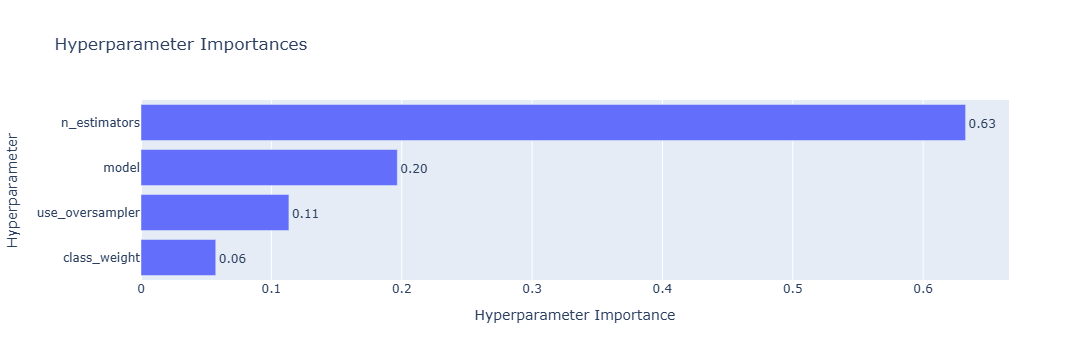

In [16]:
from optuna.visualization import plot_param_importances, plot_optimization_history

 # evolução do F1 ao longo dos trials
plot_param_importances(study)     # quais hiperparâmetros mais impactaram

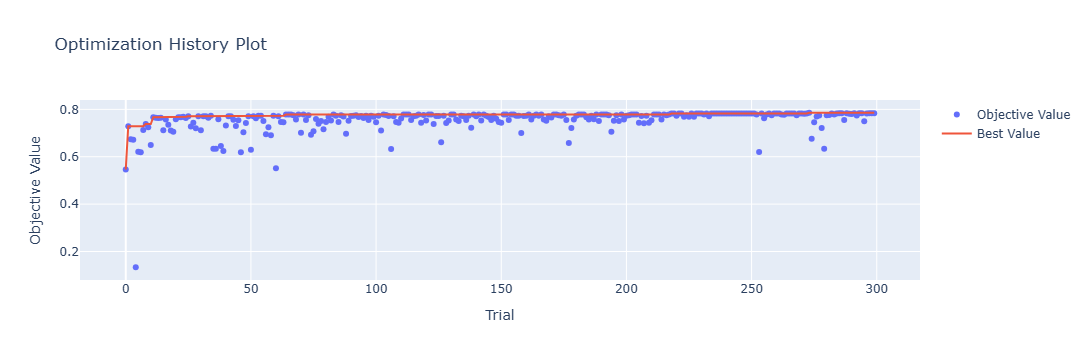

In [17]:
plot_optimization_history(study)

In [1]:
study.best_params

NameError: name 'study' is not defined

The bellow cell is only to be run if you did not ran the optuna optimizer. THese are the results I got from the optimization.

In [29]:
model = XGBClassifier(
            learning_rate    = 0.11221,
            n_estimators     = 974,
            max_depth        = 10,
            subsample        = 0.9993,
            colsample_bytree = 0.6176,
            min_child_weight = 3,
            gamma            = 1.1152,
            random_state = 42,
            n_jobs = -1,
)  



pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   MultiOutputClassifier(model))
])

In [30]:
pipelines_resultados['XGB_Tuned'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test), target_names=list(Y.columns)),multilabel_confusion_matrix(y_test,pipe.predict(x_test))]




C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:42:18] WARNING: D:\bld\xgboost-split_1768313915774\work\src\learner.cc:790: 
Parameters: { "class_weight", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:42:18] WARNING: D:\bld\xgboost-split_1768313915774\work\src\learner.cc:790: 
Parameters: { "class_weight", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:42:19] WARNING: D:\bld\xgboost-split_1768313915774\work\src\learner.cc:790: 
Parameters: { "class_weight", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:42:20] WARNING: D:\bld\xgboost-split_1768313915774\work\src\learner.cc:790: 
Parameter

In [41]:
params = {'n_estimators': 116,
 'criterion': 'log_loss',
 'min_samples_split': 8,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'ccp_alpha': 0.0008972512738601409,
         }


model = RandomForestClassifier(
            **params,
            class_weight = 'balanced',
            random_state = 42,
)  


pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   MultiOutputClassifier(model))
])

In [42]:
pipelines_resultados['RFC_Single'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test), target_names=list(Y.columns)),multilabel_confusion_matrix(y_test,pipe.predict(x_test))]


C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Use

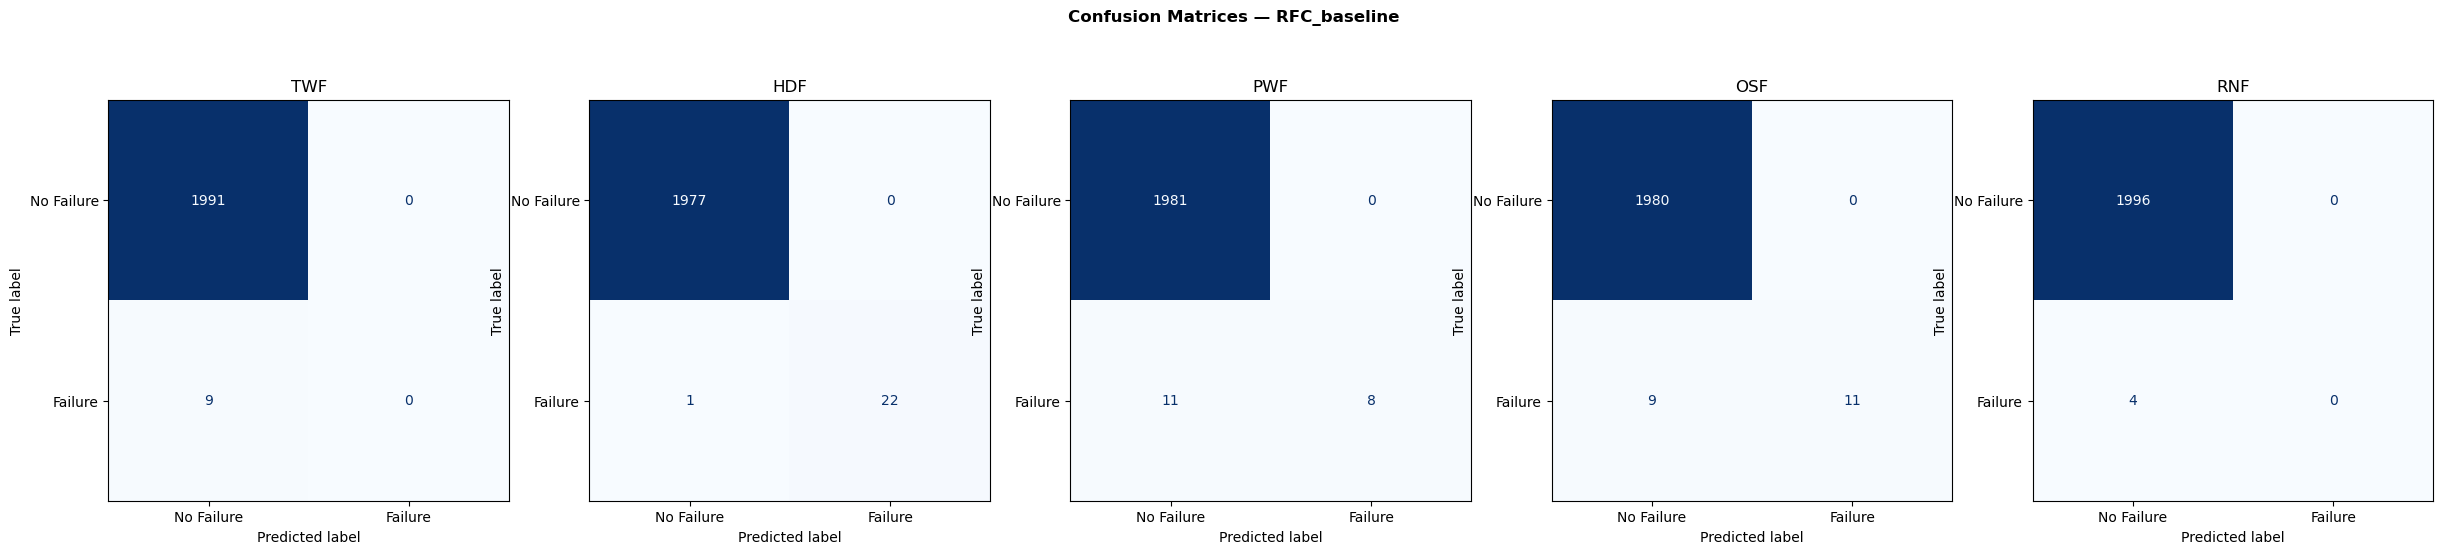

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(30,6))
label_names = Y.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_baseline'][-1][i], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[0]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()

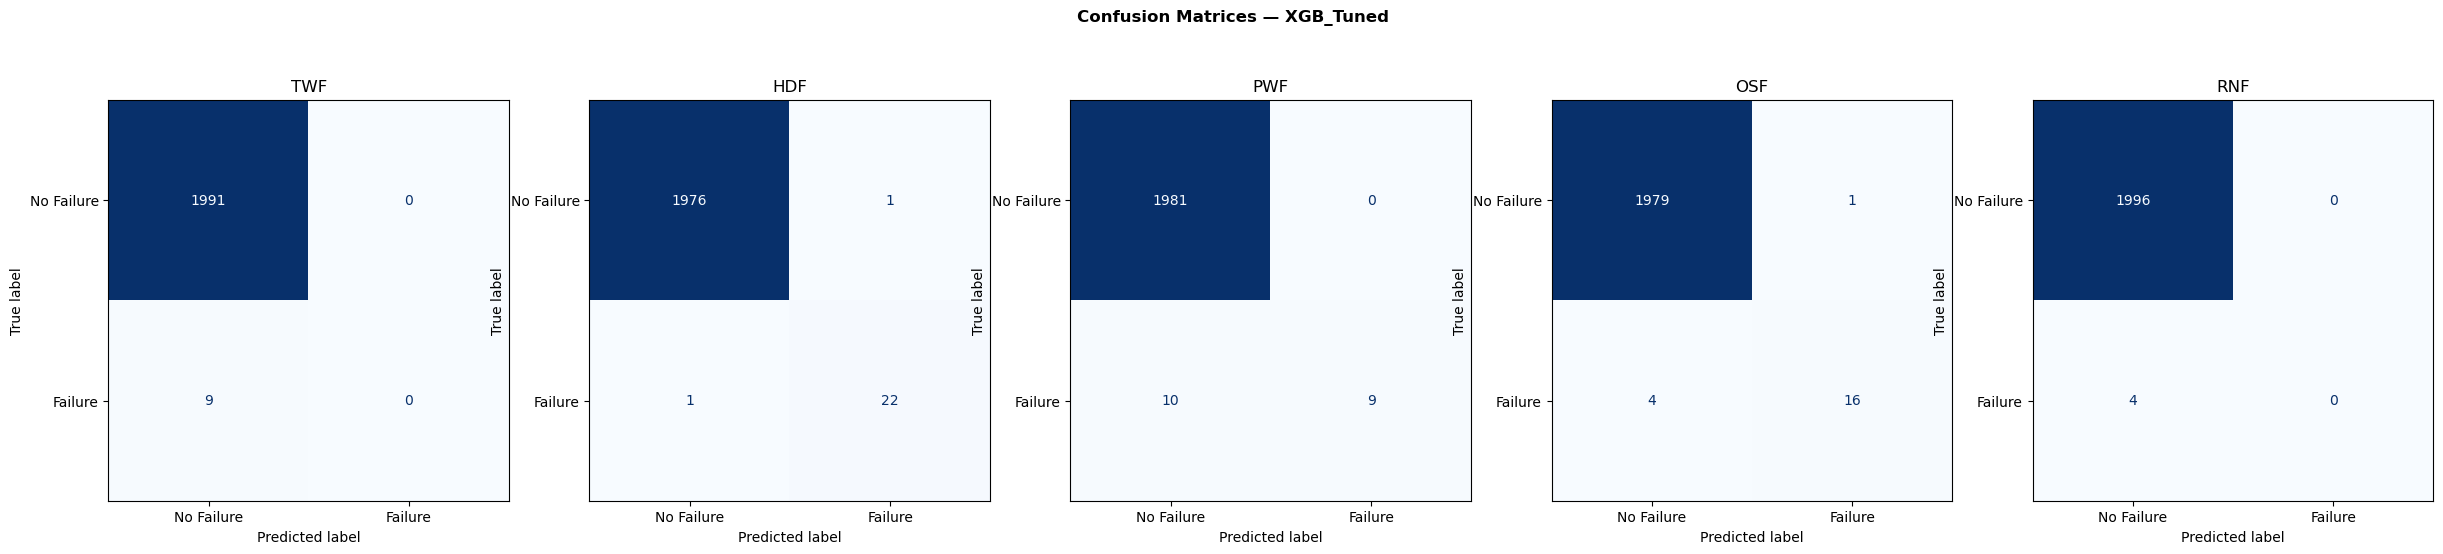

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(30,6))
label_names = Y.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['XGB_Tuned'][-1][i], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[1]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()

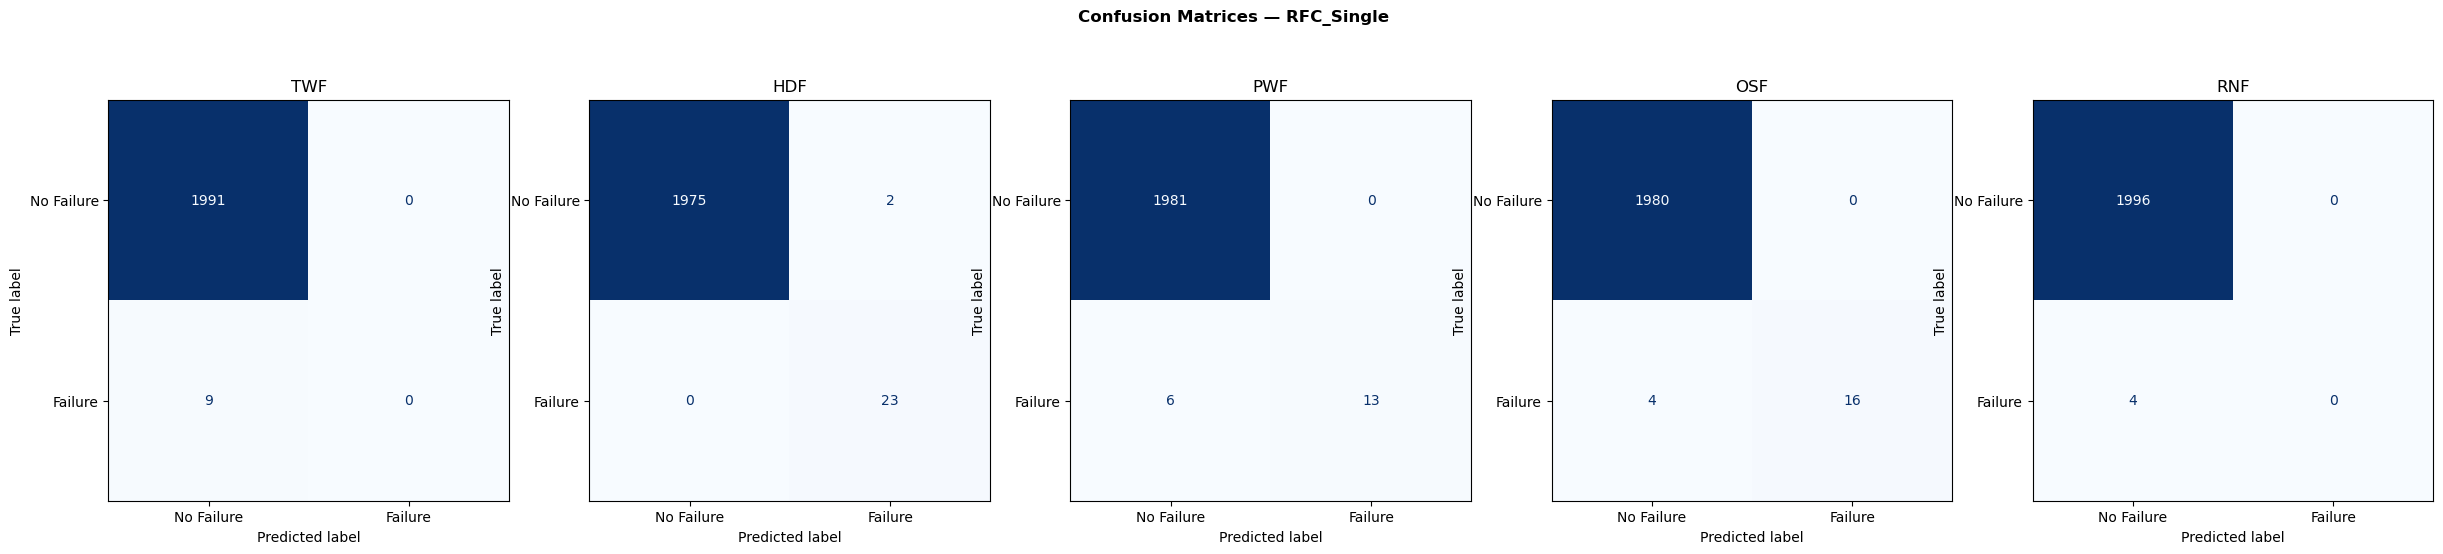

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(30,6))
label_names = Y.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Single'][-1][i], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[-1]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()

In [64]:
for k in pipelines_resultados:
    print(f" Prediction performance for {k}\n\n"
         f"{pipelines_resultados[k][4]}\n")

 Prediction performance for RFC_baseline

              precision    recall  f1-score   support

         TWF       0.00      0.00      0.00         9
         HDF       1.00      0.96      0.98        23
         PWF       1.00      0.42      0.59        19
         OSF       1.00      0.55      0.71        20
         RNF       0.00      0.00      0.00         4

   micro avg       1.00      0.55      0.71        75
   macro avg       0.60      0.39      0.46        75
weighted avg       0.83      0.55      0.64        75
 samples avg       0.02      0.02      0.02        75


 Prediction performance for XGB_Tuned

              precision    recall  f1-score   support

         TWF       0.00      0.00      0.00         9
         HDF       0.96      0.96      0.96        23
         PWF       1.00      0.47      0.64        19
         OSF       0.94      0.80      0.86        20
         RNF       0.00      0.00      0.00         4

   micro avg       0.96      0.63      0.76      

We can see that even though we had optimized a model with optuna, the model that best predicted our individual failures was the one selected in the single failure lab.

We can also see that our model does no see any random noise failure, which was expected, but also cannot predict well the TWF. There as a hint that this target might be problematic to predict, and our models confirmed it. This target alone will be analyzed in a notebook for itself.

For PWF, OSF and HDF failures, let's see how many failure predictions were correct, and how much was a false positive or a false negative:

In [75]:
pipelines_resultados[k][-1]

array([[[1991,    0],
        [   9,    0]],

       [[1977,    0],
        [   1,   22]],

       [[1981,    0],
        [  11,    8]],

       [[1980,    0],
        [   9,   11]],

       [[1996,    0],
        [   4,    0]]])

In [85]:
for k in pipelines_resultados:
    
    print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][:,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][:,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][:,1,0].sum()}\n\n"
         )
         

 Sum of correct predictions for RFC_baseline: 41
 Sum of correct False Positives for RFC_baseline: 0
 Sum of correct False Negatives for RFC_baseline: 34


 Sum of correct predictions for XGB_Tuned: 47
 Sum of correct False Positives for XGB_Tuned: 2
 Sum of correct False Negatives for XGB_Tuned: 28


 Sum of correct predictions for RFC_Single: 52
 Sum of correct False Positives for RFC_Single: 2
 Sum of correct False Negatives for RFC_Single: 23




Now, not considering RNF and TWF, the results are:

In [86]:
for k in pipelines_resultados:
    
    print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][1:4,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][1:4,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][1:4,1,0].sum()}\n\n"
         )

 Sum of correct predictions for RFC_baseline: 41
 Sum of correct False Positives for RFC_baseline: 0
 Sum of correct False Negatives for RFC_baseline: 21


 Sum of correct predictions for XGB_Tuned: 47
 Sum of correct False Positives for XGB_Tuned: 2
 Sum of correct False Negatives for XGB_Tuned: 15


 Sum of correct predictions for RFC_Single: 52
 Sum of correct False Positives for RFC_Single: 2
 Sum of correct False Negatives for RFC_Single: 10




Now our model correctly predicted 52 out of 64 failures between OSF, PWF and HDF. This kind of failures usually are tied to higher cost in maintenance when compared to TWF (nothing can be assumed by RNF, as they are random failure).

This gives our model a competitive edge to our maintenance team, by correctly pointing out what failures are about to happen in our machinery. Before ending this lab. Let's explore another alternative for our prediction model.

### Model Simplification

We used a model called multi labelled, which assumes that multiple failures are somehow coupled, and we did a more complete assessment of the problem. Since our model could not predict any Random Noise Failure, nor Tool Wear Failure, let's check again what kind of interactions we have between HDF, OSF and PWF, and if we can simplify our multi labelled model, to a multiclass label:

In [90]:
Y_new = Y.drop(columns = ['TWF','RNF'])

print(Y_new.shape)        # (n_amostras, 5) → multi-label
print(Y_new.sum(axis=1).max()) 
print(Y_new.sum(axis=1).value_counts().sort_index())

# How many simultaneous failures exists
print(Y_new.astype(str).apply('_'.join, axis=1).value_counts().head(20))

print(f"Percentage of multiple failures occuring at once: {((Y_new.sum(axis=1)==2)|(Y_new.sum(axis=1) == 3)).sum()/(Y_new.sum(axis=1)==1).sum():.2%}")

(10000, 3)
2
0    9713
1     266
2      21
Name: count, dtype: int64
0_0_0    9713
1_0_0     106
0_1_0      80
0_0_1      80
0_1_1      12
1_0_1       6
1_1_0       3
Name: count, dtype: int64
Percentage of multiple failures occuring at once: 7.89%


So, our model still mantains about 7% of multiple failures at once. Let's check if our models performs better without the TWF and RNF targets. We will only check the random forests classificator

In [93]:
mss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in mss.split(X, Y_new):
    x_train, x_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = Y_new.iloc[train_idx], Y_new.iloc[test_idx]

cv = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

model = RandomForestClassifier(
            **params,
            class_weight = 'balanced',
            random_state = 42,
)  


pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   MultiOutputClassifier(model))
])

In [95]:
pipelines_resultados['RFC_Single_Simplified'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test), target_names=list(Y_new.columns)),multilabel_confusion_matrix(y_test,pipe.predict(x_test))]


C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

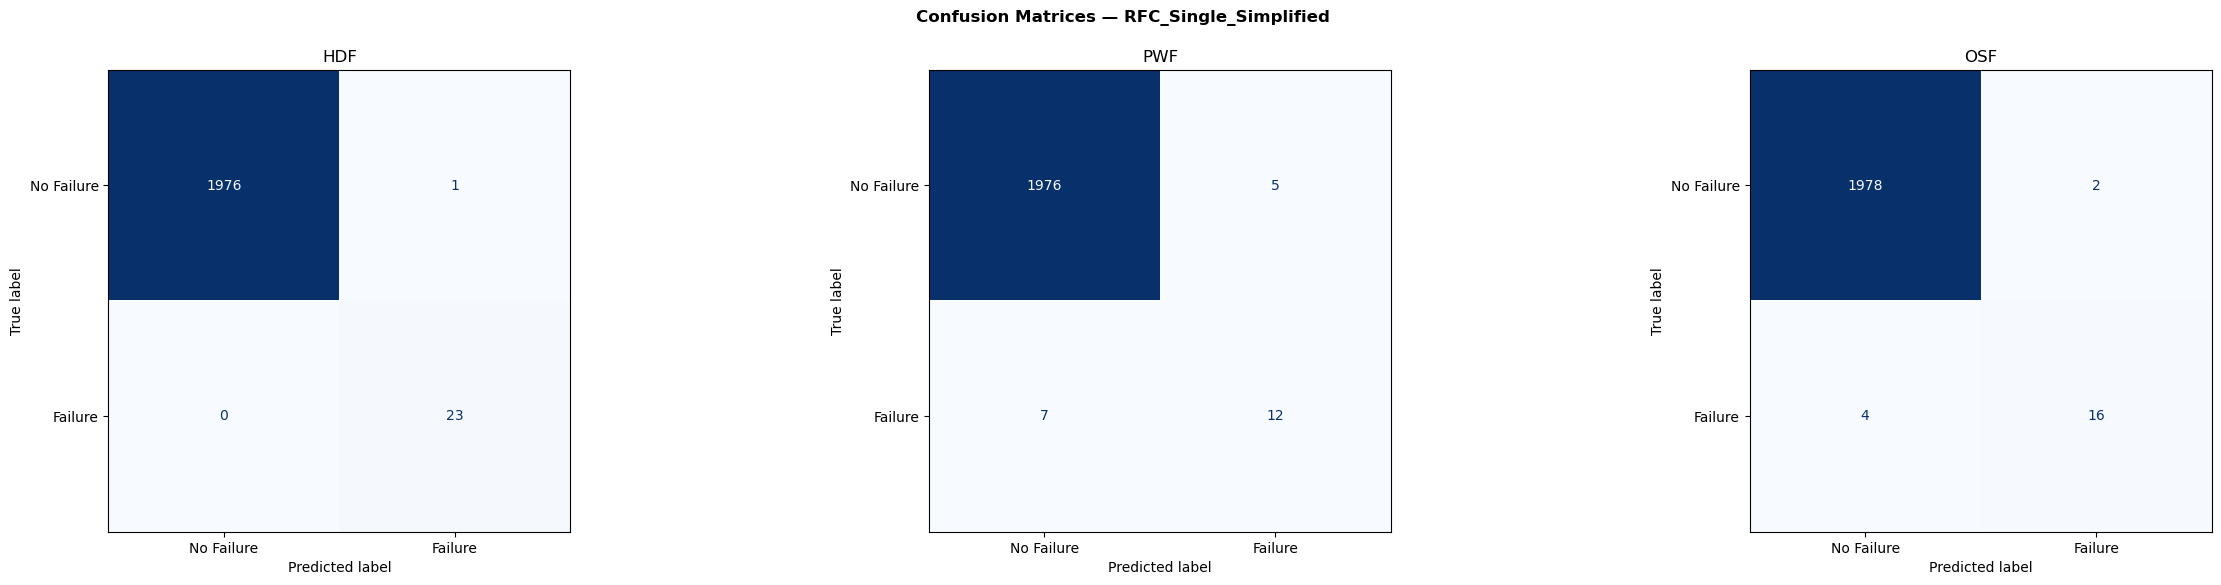

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(30,6))
label_names = Y_new.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Single_Simplified'][-1][i], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[-1]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()

In [103]:
for i,k in enumerate(pipelines_resultados):
    if i < 2:
        continue
    elif i == 2:
        print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][1:4,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][1:4,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][1:4,1,0].sum()}\n\n"
         )
    else:
        print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][:,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][:,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][:,1,0].sum()}\n\n"
         )

 Sum of correct predictions for RFC_Single: 52
 Sum of correct False Positives for RFC_Single: 2
 Sum of correct False Negatives for RFC_Single: 10


 Sum of correct predictions for RFC_Single_Simplified: 51
 Sum of correct False Positives for RFC_Single_Simplified: 8
 Sum of correct False Negatives for RFC_Single_Simplified: 11




Como podemos notar, a performance foi pior, aumentando a soma de falsos positivos e negativos de 12 para 19. Vamos fazer um tunning rápido de hiperparâmetros para recalibrar nosso modelo, e ver se há alguma melhora:

In [121]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import average_precision_score
class MultiLabelOversampledCV:
    """Aplica oversampling apenas no fold de treino, sem data leakage"""
    
    def __init__(self, estimator, cv, use_oversampler=True):
        self.estimator = estimator
        self.cv = cv
        self.use_oversampler = use_oversampler
    
    def score(self, X, y):
        scores = []
        
        # Mantém como DataFrame para preservar nomes das colunas
        X_df  = X.reset_index(drop=True)
        y_arr = y.values if hasattr(y, 'values') else y
        
        for train_idx, test_idx in self.cv.split(X_df, y_arr):
            X_train_fold = X_df.iloc[train_idx]
            X_test_fold  = X_df.iloc[test_idx]
            y_train_fold = y_arr[train_idx]
            y_test_fold  = y_arr[test_idx]
            
            if self.use_oversampler:
                # Converte multilabel → string para o RandomOverSampler aceitar
                y_str = [''.join(map(str, row)) for row in y_train_fold]
                ros   = RandomOverSampler(random_state=42)
                X_train_fold, y_str_res = ros.fit_resample(X_train_fold, y_str)
                y_train_fold = np.array([[int(c) for c in s] for s in y_str_res])
                
                # Reconverte X para DataFrame preservando colunas
                X_train_fold = pd.DataFrame(X_train_fold, columns=X_df.columns)
            
            self.estimator.fit(X_train_fold, y_train_fold)
            y_pred = self.estimator.predict(X_test_fold)
            scores.append(f1_score(y_test_fold, y_pred, average='weighted', zero_division=0))
        
        return np.mean(scores)
        
    def objective(trial):

        model = RandomForestClassifier(
            n_estimators      = trial.suggest_int('n_estimators', 200, 500),
            max_depth         = trial.suggest_int('max_depth', 10, 25),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
            max_features      = trial.suggest_float('max_features', 0.3, 0.9),
            class_weight      = 'balanced',
            random_state      = 42,
            n_jobs = -1
        )


        pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   MultiOutputClassifier(model))
    ])
    
        cv_runner = MultiLabelOversampledCV(
        estimator      = pipe,
        cv             = cv
    )

        return cv_runner.score(x_train, y_train)

In [122]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), pruner = optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Melhor F1-micro:     {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

[I 2026-03-11 13:26:31,693] A new study created in memory with name: no-name-41cc0089-987f-4eab-a4ba-0d20123f17dc
Best trial: 0. Best value: 0.825642:   2%|▏         | 1/50 [00:29<23:57, 29.34s/it]

[I 2026-03-11 13:27:01,018] Trial 0 finished with value: 0.8256422820814431 and parameters: {'n_estimators': 312, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.39361118426546193}. Best is trial 0 with value: 0.8256422820814431.


Best trial: 0. Best value: 0.825642:   4%|▍         | 2/50 [00:51<20:13, 25.29s/it]

[I 2026-03-11 13:27:23,476] Trial 1 finished with value: 0.7215611528836499 and parameters: {'n_estimators': 246, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 0.7248435466776273}. Best is trial 0 with value: 0.8256422820814431.


Best trial: 2. Best value: 0.873827:   6%|▌         | 3/50 [01:11<17:59, 22.96s/it]

...

[I 2026-03-11 13:47:36,010] Trial 47 finished with value: 0.8792362539175347 and parameters: {'n_estimators': 214, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 0.6902726401153358}. Best is trial 45 with value: 0.8833998677374468.


Best trial: 45. Best value: 0.8834:  98%|█████████▊| 49/50 [21:27<00:22, 22.57s/it]

[I 2026-03-11 13:47:59,393] Trial 48 finished with value: 0.8833998677374468 and parameters: {'n_estimators': 260, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 0.725558911993338}. Best is trial 45 with value: 0.8833998677374468.


Best trial: 45. Best value: 0.8834: 100%|██████████| 50/50 [22:00<00:00, 26.41s/it]

[I 2026-03-11 13:48:32,350] Trial 49 finished with value: 0.8780647918351647 and parameters: {'n_estimators': 332, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 0.7349240611387656}. Best is trial 45 with value: 0.8833998677374468.
Melhor F1-micro:     0.8834
Melhores parâmetros: {'n_estimators': 255, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 0.7165080365622296}


In [117]:
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Melhor F1-micro:     {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

Best trial: 48. Best value: 0.882843:   2%|▏         | 1/50 [00:37<30:17, 37.09s/it]

[I 2026-03-11 12:20:46,700] Trial 50 finished with value: 0.8614445942407108 and parameters: {'n_estimators': 413, 'max_depth': 18, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 0.6355764288958174}. Best is trial 48 with value: 0.8828433971526755.


Best trial: 48. Best value: 0.882843:   4%|▍         | 2/50 [01:19<32:12, 40.26s/it]

[I 2026-03-11 12:21:29,172] Trial 51 finished with value: 0.8828433971526755 and parameters: {'n_estimators': 466, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.6743528326994042}. Best is trial 48 with value: 0.8828433971526755.


Best trial: 48. Best value: 0.882843:   6%|▌         | 3/50 [02:00<31:42, 40.49s/it]

...

[I 2026-03-11 12:42:58,727] Trial 97 finished with value: 0.8862942583482175 and parameters: {'n_estimators': 243, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 0.7672840658347788}. Best is trial 81 with value: 0.8862942583482175.


Best trial: 81. Best value: 0.886294:  98%|█████████▊| 49/50 [23:11<00:22, 22.28s/it]

[I 2026-03-11 12:43:21,329] Trial 98 finished with value: 0.8862942583482175 and parameters: {'n_estimators': 242, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 0.7631010271727814}. Best is trial 81 with value: 0.8862942583482175.


Best trial: 81. Best value: 0.886294: 100%|██████████| 50/50 [23:35<00:00, 28.30s/it]

[I 2026-03-11 12:43:44,797] Trial 99 finished with value: 0.8242517115700523 and parameters: {'n_estimators': 252, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.7661445341212558}. Best is trial 81 with value: 0.8862942583482175.
Melhor F1-micro:     0.8863
Melhores parâmetros: {'n_estimators': 253, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 0.7430318036721283}


In [123]:
print(f"Melhor F1-micro:     {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

Melhor F1-micro:     0.8834
Melhores parâmetros: {'n_estimators': 255, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 0.7165080365622296}


In [124]:
model = RandomForestClassifier(
            **study.best_params,
            class_weight = 'balanced',
            random_state = 42,
)  


pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   MultiOutputClassifier(model))
])

pipelines_resultados['RFC_Simplified_Optimized'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test), target_names=list(Y_new.columns)),multilabel_confusion_matrix(y_test,pipe.predict(x_test))]


C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

In [125]:
for i,k in enumerate(pipelines_resultados):
    if i < 2:
        continue
    elif i == 2:
        print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][1:4,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][1:4,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][1:4,1,0].sum()}\n\n"
         )
    else:
        print(f" Sum of correct predictions for {k}: {pipelines_resultados[k][-1][:,1,1].sum()}\n"
          f" Sum of correct False Positives for {k}: {pipelines_resultados[k][-1][:,0,1].sum()}\n"
          f" Sum of correct False Negatives for {k}: {pipelines_resultados[k][-1][:,1,0].sum()}\n\n"
         )

 Sum of correct predictions for RFC_Single: 52
 Sum of correct False Positives for RFC_Single: 2
 Sum of correct False Negatives for RFC_Single: 10


 Sum of correct predictions for RFC_Single_Simplified: 51
 Sum of correct False Positives for RFC_Single_Simplified: 8
 Sum of correct False Negatives for RFC_Single_Simplified: 11


 Sum of correct predictions for RFC_Simplified_Optimized: 55
 Sum of correct False Positives for RFC_Simplified_Optimized: 23
 Sum of correct False Negatives for RFC_Simplified_Optimized: 7




After trying to simplify and tune our model, it is clear that our optimized model including all 5 modes of failure, was the best model to predict whether a failure is about to happen or not. The parameters are the following:

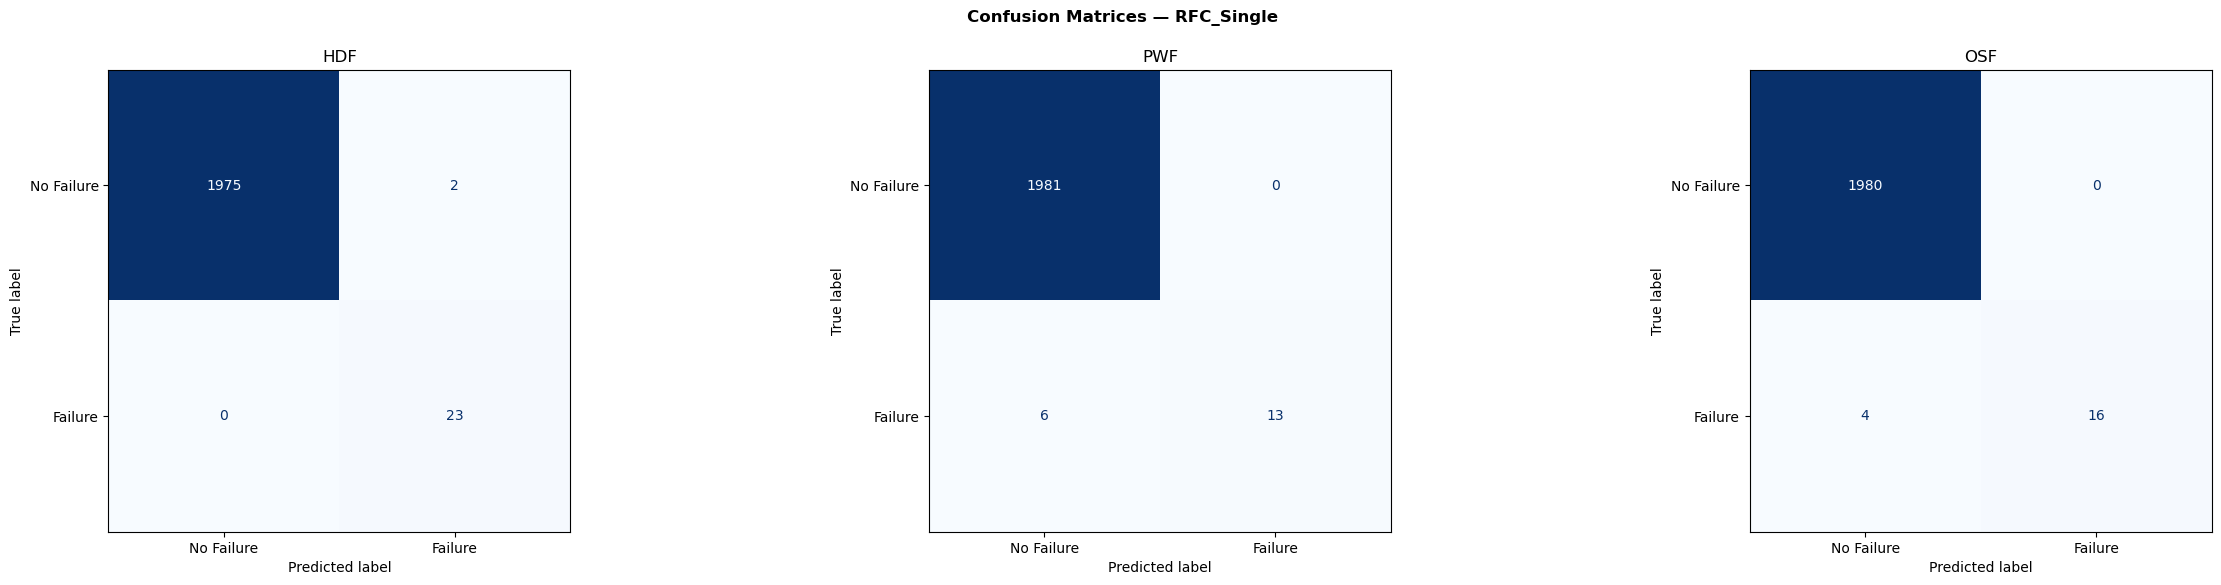

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [130]:
fig, axes = plt.subplots(1, 3, figsize=(30,6))
label_names = Y_new.columns.tolist()

for i, (ax, label) in enumerate(zip(axes, label_names)):
    ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Single'][-1][i+1], display_labels=['No Failure', 'Failure']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label)

plt.suptitle(f'Confusion Matrices — {list(pipelines_resultados.keys())[2]}', fontweight='bold')
#plt.title(f'Matriz de Confusão - {}')
plt.show()
pipelines_resultados['RFC_Single'][0]

## Final results:

 Sum of correct predictions for RFC_Single: 52
 Sum of correct False Positives for RFC_Single: 2
 Sum of correct False Negatives for RFC_Single: 10

 Considering only the PWF, OSF and HDF failure modes, but also using data from RNF and TWF.

## Conslusions

Our model predicted with good precision 3 out of 5 failure modes, being these modes OSF, HDF and PWF, even though it had to be trained alongside RNF and TWF to have a better performance.

When the target variables were reduced to only 3 targets, the model started to lose precision and recall, increasing the sum of false positives and negatives from 12 to 19 with our Random Forest Classifier.

The features used, were the same provided in the previous notebook, so no changes were made here. Maybe some feature engineering could improve in the model's performance, but at this time, it is beyond the scope of this work.

The parameters used can be seen in the cell above.

In th